# Overnight Gap Screener — Bloomberg (`xbbg` / `blpapi`)

**Objective.** Each afternoon, rank a stock universe by *expected overnight return* and produce a
long / short candidate list to be entered near today's close and exited at tomorrow's open.

## Trade definition

| Item | Choice |
|---|---|
| **Signal timestamp** | `T-5min` = 15:55 exchange time (configurable) |
| **Target variable** | `Open(t+1) / P(t, 15:55) − 1` |
| **Assumed entry fill** | Closing auction print (`PX_LAST`), *not* the 15:55 price |
| **Assumed exit fill** | Opening auction print (`PX_OPEN` of t+1) |
| **Holding period** | ~17.5 hours, no intraday exposure |

The 15:55 timestamp exists because a market-on-close order must be submitted before the exchange
cutoff (15:50 NYSE/Nasdaq for regular MOC). You need the signal *before* you can send the order, so
the signal cannot use the closing price itself. This notebook keeps that distinction explicit:
`P(t, 15:55)` drives the **signal**, the auction prices drive the **P&L**.

## What actually predicts overnight returns

The economic content of the model is the *intraday-to-overnight reversal* documented by Lou, Polk &
Skouras and others: the overnight and intraday components of daily returns are persistently
negatively correlated in the cross-section. Layered on top:

- **late-session momentum** — the last 30 minutes carry informed flow that continues into the open
- **stock-level overnight premium** — some names structurally earn their return overnight
- **short interest** — heavily shorted names show different gap behaviour
- **size / illiquidity** — the effect is far stronger in small, illiquid names, where it is also far
  harder to monetise

## Read this before trusting any number below

The gross edge in overnight reversal is on the order of **5–20 bps/day** in a liquid universe. The
strategy turns over **100% every single day**, and you cross the spread four times per unit of
book capital per day. Transaction costs are not a footnote here — they are the entire question. The
notebook computes an explicit **breakeven cost** so you can see how much room you have before you
build anything on top of it.

This is research scaffolding, not investment advice, and not a validated strategy.

---
## 1. Configuration

In [18]:
from dataclasses import dataclass, field
from typing import Tuple
import datetime as dt

@dataclass
class Config:
    # --- universe -------------------------------------------------------
    UNIVERSE_INDEX: str = "SPX Index"      # resolved via bds(..., 'INDX_MEMBERS')
    MANUAL_UNIVERSE: Tuple[str, ...] = ()  # non-empty overrides the index
    UNIVERSE_CAP: int = 500                # hard cap on tickers (Bloomberg data limits)

    # --- history --------------------------------------------------------
    HISTORY_YEARS: int = 6
    INTRADAY_LOOKBACK_DAYS: int = 45       # bdib retains only ~140 calendar days

    # --- signal timing --------------------------------------------------
    EXCHANGE_CLOSE: str = "16:00"
    EXCHANGE_TZ: str = "America/New_York"
    SNAPSHOT_MIN_BEFORE_CLOSE: int = 5     # -> 15:55 signal timestamp
    LATE_MOMENTUM_WINDOW_MIN: int = 30     # late-session return window

    # --- model ----------------------------------------------------------
    TRAIN_WINDOW_DAYS: int = 504           # ~2y rolling training window
    MIN_TRAIN_DAYS: int = 120
    REFIT_EVERY_DAYS: int = 21             # refit monthly, not daily
    RIDGE_ALPHA: float = 25.0
    WINSOR_Z: float = 3.0
    DEMEAN_TARGET: bool = True             # market-neutralise the target each day

    # --- portfolio ------------------------------------------------------
    N_LONG: int = 20
    N_SHORT: int = 20

    # --- liquidity / eligibility filters --------------------------------
    MIN_PRICE: float = 5.0
    MIN_ADV_USD: float = 2.0e7
    MAX_SPREAD_BPS: float = 15.0
    EXCLUDE_EARNINGS_TONIGHT: bool = True
    EARNINGS_BLACKOUT_DAYS: int = 1        # exclude if reporting within N days

    # --- costs ----------------------------------------------------------
    ONE_WAY_COST_BPS: float = 5.0          # half-spread + impact + fees, per one-way trade
    # A $1-long / $1-short book trades $2 in and $2 out each day = 4 one-way
    # trades per $1 of quoted capital.
    COST_MULTIPLIER: float = 4.0

    # --- execution mode -------------------------------------------------
    DEMO_MODE: bool = True                 # True -> synthetic data, no terminal required
    OUTPUT_DIR: str = "."

CFG = Config()
CFG

Config(UNIVERSE_INDEX='SPX Index', MANUAL_UNIVERSE=(), UNIVERSE_CAP=500, HISTORY_YEARS=6, INTRADAY_LOOKBACK_DAYS=45, EXCHANGE_CLOSE='16:00', EXCHANGE_TZ='America/New_York', SNAPSHOT_MIN_BEFORE_CLOSE=5, LATE_MOMENTUM_WINDOW_MIN=30, TRAIN_WINDOW_DAYS=504, MIN_TRAIN_DAYS=120, REFIT_EVERY_DAYS=21, RIDGE_ALPHA=25.0, WINSOR_Z=3.0, DEMEAN_TARGET=True, N_LONG=20, N_SHORT=20, MIN_PRICE=5.0, MIN_ADV_USD=20000000.0, MAX_SPREAD_BPS=15.0, EXCLUDE_EARNINGS_TONIGHT=True, EARNINGS_BLACKOUT_DAYS=1, ONE_WAY_COST_BPS=5.0, COST_MULTIPLIER=4.0, DEMO_MODE=True, OUTPUT_DIR='.')

In [19]:
import os, warnings, math
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.width", 190)
pd.set_option("display.max_columns", 40)

# --- Bloomberg connectivity -------------------------------------------
BBG_AVAILABLE = False
blp = None
try:
    from xbbg import blp as _blp          # pip install xbbg (needs blpapi + running Terminal)
    _blp.bdp("SPY US Equity", "PX_LAST")  # probe the session
    blp = _blp
    BBG_AVAILABLE = True
except Exception as exc:                   # ImportError, session failure, no terminal, ...
    print(f"[bbg] unavailable -> {type(exc).__name__}: {exc}")

if not BBG_AVAILABLE:
    CFG.DEMO_MODE = True

print(f"Bloomberg session : {'LIVE' if BBG_AVAILABLE else 'not connected'}")
print(f"Mode              : {'DEMO (synthetic data)' if CFG.DEMO_MODE else 'LIVE Bloomberg data'}")

[bbg] unavailable -> ModuleNotFoundError: No module named 'xbbg'
Bloomberg session : not connected
Mode              : DEMO (synthetic data)


---
## 2. Bloomberg field map

Field mnemonics drift between Bloomberg releases, asset classes and entitlements. **Verify every
mnemonic below against `FLDS <GO>`** on your terminal before running live — the field-probe cell
underneath tells you which ones your account actually returns data for.

| Purpose | Field | Call |
|---|---|---|
| Index constituents | `INDX_MEMBERS` | `bds` |
| Daily OHLCV | `PX_OPEN`, `PX_HIGH`, `PX_LOW`, `PX_LAST`, `PX_VOLUME` | `bdh` |
| VWAP | `EQY_WEIGHTED_AVG_PX` | `bdh` |
| 1-minute bars | *(TRADE bars)* | `bdib` |
| Live quote | `BID`, `ASK`, `PX_LAST`, `PX_OPEN`, `VOLUME` | `bdp` |
| Market cap / float | `CUR_MKT_CAP`, `EQY_FLOAT`, `EQY_SH_OUT` | `bdp` |
| Realised vol | `VOLATILITY_20D`, `VOLATILITY_30D` | `bdp` / `bdh` |
| Short interest | `SI_PERCENT_EQY_FLOAT`, `SHORT_INT_RATIO` | `bdp` |
| Avg volume | `VOLUME_AVG_20D` | `bdp` |
| Next earnings | `EXPECTED_REPORT_DT` | `bdp` |
| Last earnings | `LATEST_ANNOUNCEMENT_DT` | `bdp` |
| Primary exchange | `EQY_PRIM_EXCH_SHRT` | `bdp` |

`bdh` is called with `CshAdjNormal=True, CshAdjAbnormal=True, CapChg=True` so the OHLC series is
fully adjusted for splits and dividends — critical here, because an unadjusted split produces a
fake overnight gap of −50% and will dominate any model you fit.

In [20]:
DAILY_FLDS = ["PX_OPEN", "PX_HIGH", "PX_LOW", "PX_LAST", "PX_VOLUME"]

STATIC_FLDS = [
    "NAME", "CUR_MKT_CAP", "EQY_FLOAT", "VOLUME_AVG_20D", "VOLATILITY_20D",
    "SI_PERCENT_EQY_FLOAT", "EXPECTED_REPORT_DT", "EQY_PRIM_EXCH_SHRT", "GICS_SECTOR_NAME",
]

QUOTE_FLDS = ["PX_LAST", "BID", "ASK", "PX_OPEN", "VOLUME"]


def probe_fields(ticker: str = "AAPL US Equity", flds=None) -> pd.DataFrame:
    # Ask Bloomberg for each field individually and report which ones come back populated.
    flds = flds or (STATIC_FLDS + QUOTE_FLDS)
    if not BBG_AVAILABLE:
        return pd.DataFrame({"field": flds, "status": "not checked (no session)"})
    rows = []
    for f in flds:
        try:
            v = blp.bdp(ticker, f)
            val = v.iloc[0, 0] if len(v) and v.shape[1] else None
            rows.append({"field": f, "status": "OK" if pd.notna(val) else "EMPTY", "value": val})
        except Exception as e:
            rows.append({"field": f, "status": f"ERROR: {type(e).__name__}", "value": None})
    return pd.DataFrame(rows)


probe_fields()

,field,status
0,NAME,not checked (no session)
1,CUR_MKT_CAP,not checked (no session)
2,EQY_FLOAT,not checked (no session)
3,VOLUME_AVG_20D,not checked (no session)
4,VOLATILITY_20D,not checked (no session)
5,SI_PERCENT_EQY_FLOAT,not checked (no session)
6,EXPECTED_REPORT_DT,not checked (no session)
7,EQY_PRIM_EXCH_SHRT,not checked (no session)
8,GICS_SECTOR_NAME,not checked (no session)
9,PX_LAST,not checked (no session)


---
## 3. Data layer

Every accessor has a synthetic fallback so the whole pipeline runs end-to-end without a terminal.
The synthetic generator embeds a known intraday→overnight reversal coefficient, which doubles as a
correctness test: if the model can't recover a planted effect on clean data, the bug is in the
modelling code, not in the market.

In [21]:
DEMO_REVERSAL_BETA = -0.055   # planted: overnight(t+1) = beta * intraday(t) + noise
DEMO_LATE_BETA     =  0.030   # planted: late-session momentum continues overnight


def _demo_universe(n=120):
    rng = np.random.default_rng(0)
    letters = np.array(list("ABCDEFGHIJKLMNOPQRSTUVWXYZ"))
    seen, out = set(), []
    while len(out) < n:
        t = "".join(rng.choice(letters, 3))
        if t not in seen:
            seen.add(t)
            out.append(f"{t} US Equity")
    return out


def _demo_daily_panel(tickers, start, end, seed=7):
    # Build OHLCV with the daily return split into an overnight and an intraday leg,
    # where the overnight leg partially reverses the prior intraday leg.
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(start, end)
    nd, nt = len(dates), len(tickers)

    beta   = rng.uniform(0.6, 1.6, nt)
    sigma  = rng.uniform(0.010, 0.028, nt)
    mkt    = rng.normal(0.0003, 0.009, nd)

    intraday = mkt[:, None] * beta[None, :] * 0.65 + rng.normal(0, 1, (nd, nt)) * sigma * 0.75
    on_noise = mkt[:, None] * beta[None, :] * 0.35 + rng.normal(0, 1, (nd, nt)) * sigma * 0.55

    # late-session return: correlated with the day, plus its own information
    late = intraday * 0.30 + rng.normal(0, 1, (nd, nt)) * sigma * 0.35

    overnight = np.zeros((nd, nt))
    overnight[0] = on_noise[0]
    for i in range(1, nd):
        overnight[i] = (on_noise[i]
                        + DEMO_REVERSAL_BETA * intraday[i - 1]
                        + DEMO_LATE_BETA * late[i - 1])

    px_close = np.zeros((nd, nt)); px_open = np.zeros((nd, nt))
    prev = rng.uniform(15, 320, nt)
    for i in range(nd):
        px_open[i]  = prev * (1 + overnight[i])
        px_close[i] = px_open[i] * (1 + intraday[i])
        prev = px_close[i]

    span   = np.abs(intraday) + np.abs(rng.normal(0, 0.006, (nd, nt)))
    px_hi  = np.maximum(px_open, px_close) * (1 + span * 0.5)
    px_lo  = np.minimum(px_open, px_close) * (1 - span * 0.5)
    shares = rng.lognormal(15.5, 0.9, nt)
    vol    = shares * np.exp(rng.normal(0, 0.35, (nd, nt))) * (1 + 3 * np.abs(intraday))

    def wide(a):
        return pd.DataFrame(a, index=dates, columns=tickers)

    panel = {"PX_OPEN": wide(px_open), "PX_HIGH": wide(px_hi), "PX_LOW": wide(px_lo),
             "PX_LAST": wide(px_close), "PX_VOLUME": wide(vol)}
    # P(15:55) sits a few basis points away from the closing print
    panel["PX_T5"] = wide(px_close * (1 - intraday * 0.004 + rng.normal(0, 0.0004, (nd, nt))))
    panel["LATE_RET"] = wide(late)
    return panel

In [22]:
def get_universe(cfg=CFG):
    if cfg.MANUAL_UNIVERSE:
        return list(cfg.MANUAL_UNIVERSE)[: cfg.UNIVERSE_CAP]
    if cfg.DEMO_MODE:
        return _demo_universe(120)
    members = blp.bds(cfg.UNIVERSE_INDEX, "INDX_MEMBERS")
    col = "member_ticker_and_exchange_code"
    tickers = [f"{t} Equity" for t in members[col].tolist()]
    return tickers[: cfg.UNIVERSE_CAP]


def get_daily_panel(tickers, start, end, cfg=CFG):
    # Returns {field: DataFrame(index=date, columns=ticker)}, split/dividend adjusted.
    if cfg.DEMO_MODE:
        return _demo_daily_panel(tickers, start, end)

    frames, CHUNK = [], 50
    for i in range(0, len(tickers), CHUNK):
        chunk = tickers[i:i + CHUNK]
        df = blp.bdh(
            tickers=chunk, flds=DAILY_FLDS,
            start_date=pd.Timestamp(start).strftime("%Y-%m-%d"),
            end_date=pd.Timestamp(end).strftime("%Y-%m-%d"),
            Per="D", Fill="P", Days="A",
            CshAdjNormal=True, CshAdjAbnormal=True, CapChg=True,
        )
        frames.append(df)
        print(f"  daily {i + len(chunk):>4}/{len(tickers)}", end="\r")
    raw = pd.concat(frames, axis=1).sort_index()
    raw.columns = pd.MultiIndex.from_tuples(
        [(t, f.upper()) for t, f in raw.columns], names=["ticker", "field"]
    )
    return {f: raw.xs(f, axis=1, level="field") for f in DAILY_FLDS}


def get_static(tickers, cfg=CFG):
    if cfg.DEMO_MODE:
        rng = np.random.default_rng(3)
        return pd.DataFrame({
            "CUR_MKT_CAP":          rng.lognormal(9.6, 1.1, len(tickers)) * 1e3,
            "VOLATILITY_20D":       rng.uniform(14, 55, len(tickers)),
            "SI_PERCENT_EQY_FLOAT": rng.gamma(2.0, 1.6, len(tickers)),
            "EXPECTED_REPORT_DT":   pd.NaT,
            "GICS_SECTOR_NAME":     rng.choice(
                ["Info Tech", "Financials", "Health Care", "Industrials",
                 "Cons Disc", "Energy"], len(tickers)),
        }, index=tickers)
    out = blp.bdp(tickers, STATIC_FLDS)
    out.columns = [c.upper() for c in out.columns]
    return out.reindex(tickers)

In [23]:
def snapshot_time(trade_date, cfg=CFG):
    # Exchange-local timestamp of the signal, e.g. 15:55.
    close = pd.Timestamp(f"{pd.Timestamp(trade_date).date()} {cfg.EXCHANGE_CLOSE}",
                         tz=cfg.EXCHANGE_TZ)
    return close - pd.Timedelta(minutes=cfg.SNAPSHOT_MIN_BEFORE_CLOSE)


def get_t5_snapshot(tickers, trade_date, cfg=CFG):
    # Price T-5min before the close, plus the trailing late-session return and
    # volume accumulated so far. Returns DataFrame indexed by ticker.
    ts   = snapshot_time(trade_date, cfg)
    late = ts - pd.Timedelta(minutes=cfg.LATE_MOMENTUM_WINDOW_MIN)

    if cfg.DEMO_MODE:
        raise RuntimeError("get_t5_snapshot requires a live Bloomberg session; "
                           "in DEMO_MODE the snapshot column PX_T5 is synthesised instead.")

    rows = []
    for j, tk in enumerate(tickers, 1):
        try:
            bars = blp.bdib(ticker=tk, dt=pd.Timestamp(trade_date).strftime("%Y-%m-%d"),
                            typ="TRADE", session="day")
            if isinstance(bars.columns, pd.MultiIndex):
                bars = bars.xs(tk, axis=1, level=0)
            bars = bars.tz_convert(cfg.EXCHANGE_TZ) if bars.index.tz else bars.tz_localize(cfg.EXCHANGE_TZ)

            upto = bars.loc[:ts]
            if upto.empty:
                continue
            px_t5   = float(upto["close"].iloc[-1])
            px_open = float(bars["open"].iloc[0])
            win     = bars.loc[late:ts]
            px_late = float(win["close"].iloc[0]) if len(win) else px_t5
            rows.append({
                "ticker": tk, "PX_T5": px_t5, "PX_OPEN_TDY": px_open,
                "LATE_RET": px_t5 / px_late - 1.0,
                "HIGH_TDY": float(upto["high"].max()), "LOW_TDY": float(upto["low"].min()),
                "VOL_TDY": float(upto["volume"].sum()),
                "BARS": len(upto), "STAMP": upto.index[-1],
            })
        except Exception as e:
            print(f"  [bdib] {tk}: {type(e).__name__}: {e}")
        print(f"  intraday {j:>4}/{len(tickers)}", end="\r")
    return pd.DataFrame(rows).set_index("ticker")


def get_live_quotes(tickers, cfg=CFG):
    if cfg.DEMO_MODE:
        return pd.DataFrame(index=tickers, columns=QUOTE_FLDS, dtype=float)
    q = blp.bdp(tickers, QUOTE_FLDS)
    q.columns = [c.upper() for c in q.columns]
    q = q.reindex(tickers)
    mid = (q["BID"] + q["ASK"]) / 2.0
    q["SPREAD_BPS"] = (q["ASK"] - q["BID"]) / mid * 1e4
    return q

---
## 4. Feature construction

All features are evaluated **as of the 15:55 signal timestamp**, so nothing in `X` uses information
that only exists after the MOC cutoff. The one place this matters most is `intraday_ret`, which uses
`P(15:55) / Open` rather than `Close / Open`.

For the multi-year history, `P(15:55)` is not retrievable (`bdib` keeps ~140 days), so the daily
close stands in as its proxy. The 15:55→16:00 difference is small and close to noise, but it is a
real approximation and it biases the backtest slightly optimistic — the model is fit on a signal
marginally cleaner than the one you can actually trade.

**Two different return series are tracked, and conflating them is the classic way to fool yourself:**

- `y_signal` = `Open(t+1) / P(15:55) − 1` — what the model is fit to predict
- `y_pnl` = `Open(t+1) / Close(t) − 1` — auction-to-auction, what you can actually capture

In [24]:
def cross_section_z(df: pd.DataFrame, winsor: float = 3.0) -> pd.DataFrame:
    # Standardise each row (date) across the cross-section, then winsorise.
    mu = df.mean(axis=1)
    sd = df.std(axis=1).replace(0.0, np.nan)
    return df.sub(mu, axis=0).div(sd, axis=0).clip(-winsor, winsor)


def build_features(panel: dict, static: pd.DataFrame, cfg=CFG) -> dict:
    op, hi, lo = panel["PX_OPEN"], panel["PX_HIGH"], panel["PX_LOW"]
    cl, vo     = panel["PX_LAST"], panel["PX_VOLUME"]
    sig        = panel.get("PX_T5", cl)          # signal price: 15:55 if available, else close

    daily_ret   = cl.pct_change()
    prev_on     = op / cl.shift(1) - 1.0         # last night's gap
    intraday    = sig / op - 1.0                 # open -> 15:55
    dollar_vol  = cl * vo

    f = {}
    # --- core reversal / momentum -------------------------------------
    f["intraday_ret"]   = intraday                               # expect NEGATIVE loading
    f["prev_overnight"] = prev_on
    f["on_mean_20"]     = prev_on.rolling(20).mean()             # stock overnight premium
    f["on_share_60"]    = (prev_on.rolling(60).sum()
                           / daily_ret.abs().rolling(60).sum().replace(0, np.nan))
    f["ret_5d"]         = sig / cl.shift(5) - 1.0
    f["ret_21d"]        = sig / cl.shift(21) - 1.0
    f["ret_252d"]       = sig / cl.shift(252) - 1.0

    if "LATE_RET" in panel:
        f["late_ret"]   = panel["LATE_RET"]                      # last 30 min, expect POSITIVE

    # --- position within the day's range ------------------------------
    rng = (hi - lo).replace(0, np.nan)
    f["range_pos"]      = (sig - lo) / rng
    f["true_range"]     = rng / cl.shift(1)

    # --- flow / liquidity ---------------------------------------------
    f["vol_ratio"]      = vo / vo.rolling(20).mean().replace(0, np.nan)
    f["log_dollar_vol"] = np.log(dollar_vol.rolling(20).mean().replace(0, np.nan))
    f["amihud"]         = (daily_ret.abs() / dollar_vol.replace(0, np.nan)).rolling(20).mean() * 1e9

    # --- risk ----------------------------------------------------------
    f["vol_20d"]        = daily_ret.rolling(20).std()
    f["gap_vol_60d"]    = prev_on.rolling(60).std()

    # --- static, broadcast across dates --------------------------------
    def _broadcast(series):
        v = series.astype(float).reindex(cl.columns).values
        return pd.DataFrame(np.tile(v, (len(cl), 1)), index=cl.index, columns=cl.columns)

    if "CUR_MKT_CAP" in static:
        f["log_mktcap"] = _broadcast(np.log(static["CUR_MKT_CAP"].astype(float)))
    if "SI_PERCENT_EQY_FLOAT" in static:
        f["short_int"]  = _broadcast(static["SI_PERCENT_EQY_FLOAT"])

    return {k: v.replace([np.inf, -np.inf], np.nan) for k, v in f.items()}


def build_targets(panel: dict, cfg=CFG):
    op, cl = panel["PX_OPEN"], panel["PX_LAST"]
    sig    = panel.get("PX_T5", cl)
    y_signal = op.shift(-1) / sig - 1.0          # what the model predicts
    y_pnl    = op.shift(-1) / cl - 1.0           # auction -> auction, what you trade
    if cfg.DEMEAN_TARGET:                        # strip the market gap; this is a relative bet
        y_signal = y_signal.sub(y_signal.mean(axis=1), axis=0)
        y_pnl    = y_pnl.sub(y_pnl.mean(axis=1), axis=0)
    return y_signal, y_pnl


def assemble_panel(feats: dict, y_signal, y_pnl, cfg=CFG) -> pd.DataFrame:
    def _stack(df, name):
        return df.rename_axis(index="date", columns="ticker").stack().rename(name)

    Z = {k: cross_section_z(v, cfg.WINSOR_Z) for k, v in feats.items()}
    X = pd.concat([_stack(v, k) for k, v in Z.items()], axis=1)
    out = X.join(_stack(y_signal, "y_signal")).join(_stack(y_pnl, "y_pnl"))
    return out.sort_index()

---
## 5. Walk-forward model

Ridge regression of standardised features on the demeaned forward overnight return, refit on a
rolling window. Ridge — not a gradient-booster — because with a daily cross-section this small and a
signal-to-noise ratio this low, a flexible learner will happily memorise noise. The linear
coefficients are also directly interpretable, which is how you'll notice when the model has latched
onto something structural instead of something economic.

Strictly walk-forward: on date *t* the model has only seen data through *t−1*, and every feature is
standardised within its own date, so no future cross-sectional moments leak backwards.

In [25]:
from sklearn.linear_model import Ridge
from scipy import stats


def walk_forward_fit(data: pd.DataFrame, feature_cols, cfg=CFG):
    data  = data.dropna(subset=list(feature_cols) + ["y_signal"]).sort_index()
    dates = data.index.get_level_values("date").unique().sort_values()

    preds, coef_log = [], []
    model, last_fit = None, -10 ** 9

    for i, d in enumerate(dates):
        if i < cfg.MIN_TRAIN_DAYS:
            continue
        if model is None or (i - last_fit) >= cfg.REFIT_EVERY_DAYS:
            lo_i = max(0, i - cfg.TRAIN_WINDOW_DAYS)
            tr = data.loc[dates[lo_i]:dates[i - 1]]
            if len(tr) < 500:
                continue
            model = Ridge(alpha=cfg.RIDGE_ALPHA, fit_intercept=True)
            model.fit(tr[feature_cols].values, tr["y_signal"].values)
            last_fit = i
            coef_log.append(pd.Series(model.coef_, index=feature_cols, name=d))

        today = data.loc[(d, slice(None)), :]
        p = pd.Series(model.predict(today[feature_cols].values),
                      index=today.index, name="pred")
        preds.append(p)

    pred = pd.concat(preds)
    res  = data.loc[pred.index, ["y_signal", "y_pnl"]].join(pred)
    coefs = pd.DataFrame(coef_log)
    return res, coefs, model, list(feature_cols)


def evaluate(res: pd.DataFrame):
    ic = (res.groupby(level="date")
             .apply(lambda g: stats.spearmanr(g["pred"], g["y_signal"]).correlation
                    if g["pred"].nunique() > 2 else np.nan)
             .dropna())
    n = len(ic)
    return pd.Series({
        "days":            n,
        "mean_rank_IC":    ic.mean(),
        "IC_std":          ic.std(),
        "IC_IR":           ic.mean() / ic.std() if ic.std() else np.nan,
        "IC_t_stat":       ic.mean() / ic.std() * np.sqrt(n) if ic.std() else np.nan,
        "pct_IC_positive": (ic > 0).mean(),
    }), ic

---
## 6. Backtest and the cost question

The book is dollar-neutral: equal-weight long the top `N_LONG`, equal-weight short the bottom
`N_SHORT`, quoted on \$1 of capital per side. The position is opened into the closing auction and
closed in the opening auction, so **turnover is 100% every day**.

That means four one-way trades per unit of quoted capital daily (in and out, on each leg), hence
`COST_MULTIPLIER = 4`. At a modest 5 bps one-way that is **20 bps per day** of drag — roughly 50
percentage points a year. The `breakeven_cost_bps` figure below is the number that decides whether
any of this is worth pursuing; if it lands under ~3 bps in a large-cap universe, the honest
conclusion is that the edge exists but is not reachable through a retail or mid-tier execution stack.

In [26]:
def backtest(res: pd.DataFrame, cfg=CFG) -> tuple:
    rows = []
    for d, g in res.groupby(level="date"):
        g = g.sort_values("pred", ascending=False)
        nl, ns = min(cfg.N_LONG, len(g) // 2), min(cfg.N_SHORT, len(g) // 2)
        if nl < 3 or ns < 3:
            continue
        longs, shorts = g.head(nl), g.tail(ns)
        gross = longs["y_pnl"].mean() - shorts["y_pnl"].mean()
        rows.append({"date": d, "gross": gross,
                     "long_leg": longs["y_pnl"].mean(),
                     "short_leg": -shorts["y_pnl"].mean(),
                     "n": len(g)})

    bt = pd.DataFrame(rows).set_index("date")
    cost = cfg.COST_MULTIPLIER * cfg.ONE_WAY_COST_BPS / 1e4
    bt["cost"] = cost
    bt["net"]  = bt["gross"] - cost
    bt["cum_gross"] = (1 + bt["gross"]).cumprod() - 1
    bt["cum_net"]   = (1 + bt["net"]).cumprod() - 1
    return bt


def summarise(bt: pd.DataFrame, cfg=CFG) -> pd.DataFrame:
    out = {}
    for leg in ["gross", "net"]:
        r = bt[leg]
        ann = r.mean() * 252
        vol = r.std() * np.sqrt(252)
        dd  = ((1 + r).cumprod() / (1 + r).cumprod().cummax() - 1).min()
        out[leg] = {
            "mean_bps_per_day": r.mean() * 1e4,
            "ann_return_pct":   ann * 100,
            "ann_vol_pct":      vol * 100,
            "sharpe":           ann / vol if vol else np.nan,
            "hit_rate_pct":     (r > 0).mean() * 100,
            "max_drawdown_pct": dd * 100,
            "t_stat":           r.mean() / r.std() * np.sqrt(len(r)) if r.std() else np.nan,
        }
    s = pd.DataFrame(out)
    s.loc["breakeven_cost_bps", "gross"] = bt["gross"].mean() / cfg.COST_MULTIPLIER * 1e4
    s.loc["applied_cost_bps",   "gross"] = cfg.ONE_WAY_COST_BPS
    return s.round(3)

---
## 7. Run the pipeline

In [27]:
END   = pd.Timestamp.today().normalize()
START = END - pd.DateOffset(years=CFG.HISTORY_YEARS)

print("Resolving universe ...")
TICKERS = get_universe(CFG)
print(f"  {len(TICKERS)} tickers, e.g. {TICKERS[:5]}")

print("Fetching static data ...")
STATIC = get_static(TICKERS, CFG)

print("Fetching daily history ...")
PANEL = get_daily_panel(TICKERS, START, END, CFG)
print(f"  {PANEL['PX_LAST'].shape[0]} sessions x {PANEL['PX_LAST'].shape[1]} names")

FEATS = build_features(PANEL, STATIC, CFG)
Y_SIG, Y_PNL = build_targets(PANEL, CFG)
DATA = assemble_panel(FEATS, Y_SIG, Y_PNL, CFG)

FEATURE_COLS = [c for c in DATA.columns if c not in ("y_signal", "y_pnl")]
print(f"\n{len(FEATURE_COLS)} features: {FEATURE_COLS}")
print(f"panel rows: {len(DATA):,}")
DATA.tail(3)

Resolving universe ...
  120 tickers, e.g. ['WQN US Equity', 'HIB US Equity', 'BAE US Equity', 'VQX US Equity', 'NPZ US Equity']
Fetching static data ...
Fetching daily history ...
  1566 sessions x 120 names

17 features: ['intraday_ret', 'prev_overnight', 'on_mean_20', 'on_share_60', 'ret_5d', 'ret_21d', 'ret_252d', 'late_ret', 'range_pos', 'true_range', 'vol_ratio', 'log_dollar_vol', 'amihud', 'vol_20d', 'gap_vol_60d', 'log_mktcap', 'short_int']
panel rows: 187,920


intraday_ret  prev_overnight  on_mean_20  on_share_60    ret_5d   ret_21d  ret_252d  late_ret  range_pos  true_range  vol_ratio  log_dollar_vol    amihud  \
date       ticker                                                                                                                                                                     
2026-08-20 ZVY US Equity     -0.790506        1.752241    1.142984    -0.912435 -0.538839  0.646547 -0.786138 -1.087811  -0.634051    0.717091   0.554940       -0.288706 -0.178750   
           ZWA US Equity     -0.340980       -0.326988   -0.135746     0.345519 -1.262015 -0.080777 -0.804452  0.082604  -0.598809    0.082623   1.962891       -0.373382 -0.143291   
           ZYR US Equity     -2.148339       -1.392008    0.818592    -0.780319 -0.681148  0.553176 -0.258221 -1.021375  -0.788268    2.326361  -0.455032        0.347566 -0.214949   

                           vol_20d  gap_vol_60d  log_mktcap  short_int  y_signal  y_pnl  
date       ticker                                                                        
2026-08-20 ZVY US Equity -0.229481     0.034266    0.724818  -0.897991       NaN    NaN  
           ZWA US Equity  0.946608     0.529551    0.086005  -0.454743       NaN    NaN  
           ZYR US Equity  2.234760     0.972113   -1.474802   1.070311       NaN    NaN

In [28]:
RES, COEFS, LIVE_MODEL, FEATURE_COLS = walk_forward_fit(DATA, FEATURE_COLS, CFG)
STATS, IC = evaluate(RES)

print("--- predictive accuracy -------------------------------------")
print(STATS.round(4).to_string())

print("\n--- average ridge coefficients, in return units per 1 sd of feature ---")
print((COEFS.mean() * 1e4).sort_values().round(2).rename("bps").to_string())

if CFG.DEMO_MODE:
    # Sanity check: the synthetic data has a known planted structure.
    print(f"\n[demo] planted intraday->overnight reversal beta : {DEMO_REVERSAL_BETA:+.4f}")
    print(f"[demo] planted late-session continuation beta   : {DEMO_LATE_BETA:+.4f}")
    print("[demo] recovered sign on intraday_ret            :",
          "NEGATIVE (correct)" if COEFS["intraday_ret"].mean() < 0 else "POSITIVE (investigate)")

--- predictive accuracy -------------------------------------
days               1193.0000
mean_rank_IC          0.0548
IC_std                0.0938
IC_IR                 0.5842
IC_t_stat            20.1783
pct_IC_positive       0.7343

--- average ridge coefficients, in return units per 1 sd of feature ---
intraday_ret     -6.94
range_pos        -1.34
ret_21d          -1.07
amihud           -0.97
vol_20d          -0.64
ret_252d         -0.40
log_dollar_vol   -0.39
prev_overnight   -0.14
vol_ratio        -0.13
on_share_60      -0.06
true_range        0.22
log_mktcap        0.25
short_int         0.26
ret_5d            0.27
gap_vol_60d       0.39
on_mean_20        0.68
late_ret          2.68

[demo] planted intraday->overnight reversal beta : -0.0550
[demo] planted late-session continuation beta   : +0.0300
[demo] recovered sign on intraday_ret            : NEGATIVE (correct)


In [29]:
BT = backtest(RES, CFG)
SUMMARY = summarise(BT, CFG)
print(SUMMARY.to_string())

breakeven = BT["gross"].mean() / CFG.COST_MULTIPLIER * 1e4
print(f"\nGross edge {BT['gross'].mean()*1e4:.2f} bps/day; breakeven one-way cost "
      f"{breakeven:.2f} bps vs assumed {CFG.ONE_WAY_COST_BPS:.2f} bps.")
print("VERDICT:", "tradeable at assumed costs" if breakeven > CFG.ONE_WAY_COST_BPS
      else "NOT tradeable at assumed costs -- edge is smaller than the spread")

                     gross     net
mean_bps_per_day    19.660  -0.340
ann_return_pct      49.544  -0.856
ann_vol_pct          5.796   5.796
sharpe               8.548  -0.148
hit_rate_pct        71.836  49.958
max_drawdown_pct    -2.532 -14.933
t_stat              18.599  -0.322
breakeven_cost_bps   4.915     NaN
applied_cost_bps     5.000     NaN

Gross edge 19.66 bps/day; breakeven one-way cost 4.92 bps vs assumed 5.00 bps.
VERDICT: NOT tradeable at assumed costs -- edge is smaller than the spread


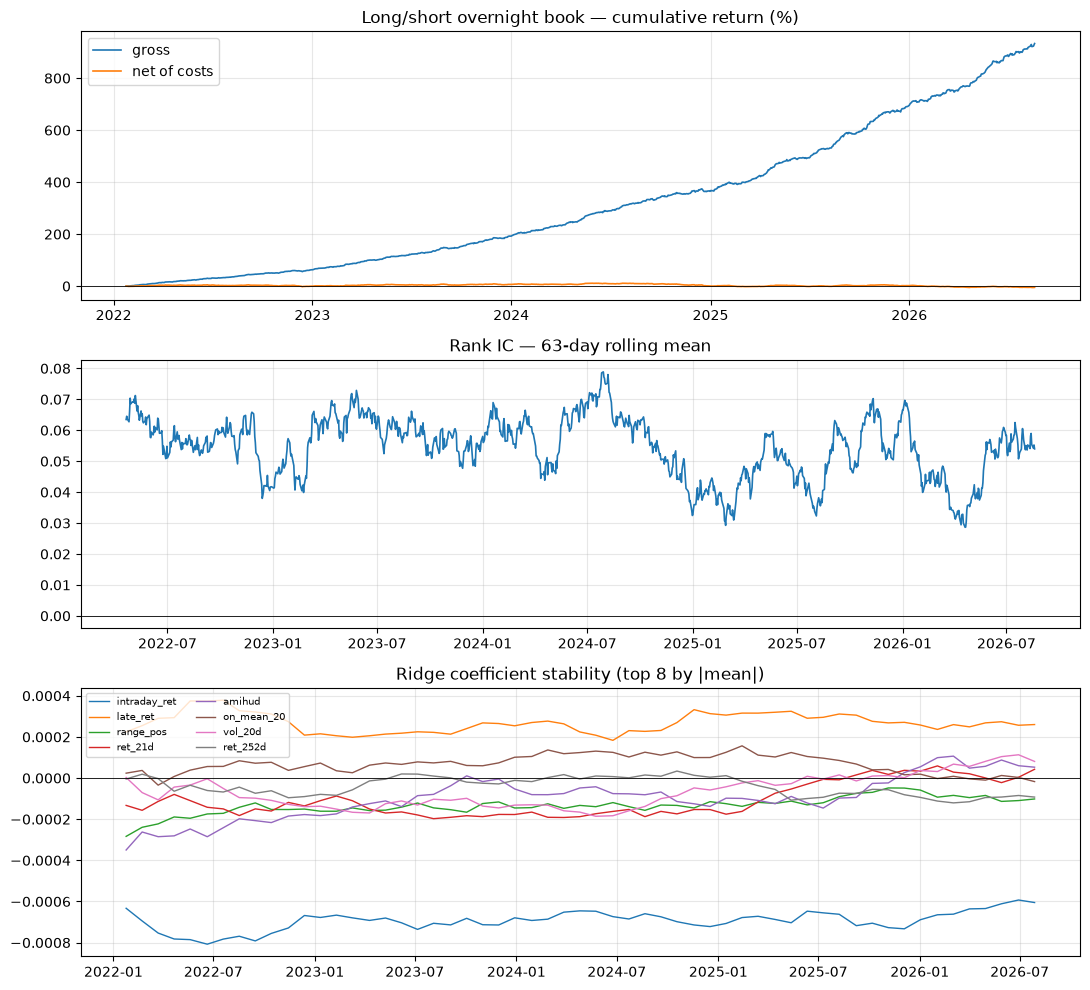

In [30]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 1, figsize=(11, 10), sharex=False)

ax[0].plot(BT.index, BT["cum_gross"] * 100, label="gross", lw=1.2)
ax[0].plot(BT.index, BT["cum_net"] * 100, label="net of costs", lw=1.2)
ax[0].axhline(0, color="k", lw=0.6)
ax[0].set_title("Long/short overnight book — cumulative return (%)")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(IC.index, IC.rolling(63).mean(), lw=1.2)
ax[1].axhline(0, color="k", lw=0.6)
ax[1].set_title("Rank IC — 63-day rolling mean")
ax[1].grid(alpha=0.3)

top = COEFS.mean().abs().sort_values(ascending=False).head(8).index
for c in top:
    ax[2].plot(COEFS.index, COEFS[c], lw=1.0, label=c)
ax[2].axhline(0, color="k", lw=0.6)
ax[2].set_title("Ridge coefficient stability (top 8 by |mean|)")
ax[2].legend(fontsize=7, ncol=2); ax[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [31]:
# Decile monotonicity: a real signal should step up across buckets, not just
# produce a wide top-minus-bottom spread driven by two extreme names.
tmp = RES.copy()
tmp["decile"] = tmp.groupby(level="date")["pred"].transform(
    lambda s: pd.qcut(s.rank(method="first"), 10, labels=False, duplicates="drop") + 1)

dec = (tmp.groupby("decile")["y_pnl"]
          .agg(mean_bps=lambda s: s.mean() * 1e4, n="size")
          .round(3))
print(dec.to_string())
print(f"\nD10 - D1 spread: {(dec.loc[10,'mean_bps'] - dec.loc[1,'mean_bps']):.2f} bps/day (gross)")

        mean_bps      n
decile                 
1        -11.709  14316
2         -7.743  14316
3         -3.093  14316
4         -2.555  14316
5         -1.737  14316
6          1.450  14316
7          2.456  14316
8          4.032  14316
9          6.005  14316
10        12.893  14316

D10 - D1 spread: 24.60 bps/day (gross)


---
## 8. Tonight's candidate list

Requires a live Bloomberg session and must be run **between ~15:55 and the MOC cutoff**. It pulls
1-minute `TRADE` bars, takes the last bar at or before 15:55, splices that price into the panel as
today's signal price, rebuilds the cross-section, and scores it with the most recently fitted model.

Eligibility filters run *after* scoring, so you can see what got dropped and why rather than having
names silently disappear.

In [32]:
def build_live_signal(cfg=CFG, trade_date=None):
    if cfg.DEMO_MODE:
        # Demo path: score the last historical cross-section instead.
        d = RES.index.get_level_values("date").max()
        live = RES.loc[(d, slice(None)), :].reset_index()
        live = live.rename(columns={"pred": "expected_on_ret"})
        live["signal_price"] = np.nan
        live["spread_bps"] = np.nan
        live["eligible"] = True
        live["exclusion"] = ""
        return live.sort_values("expected_on_ret", ascending=False), d

    trade_date = pd.Timestamp(trade_date or pd.Timestamp.today()).normalize()
    print(f"Snapshot at {snapshot_time(trade_date, cfg)} ...")
    snap = get_t5_snapshot(TICKERS, trade_date, cfg)
    if snap.empty:
        raise RuntimeError("no intraday bars returned -- check market hours / entitlements")

    # Splice today's row into the historical panel.
    p = {k: v.copy() for k, v in PANEL.items()}
    row = lambda s: pd.Series(s, index=p["PX_LAST"].columns)
    p["PX_OPEN"].loc[trade_date]   = row(snap["PX_OPEN_TDY"])
    p["PX_HIGH"].loc[trade_date]   = row(snap["HIGH_TDY"])
    p["PX_LOW"].loc[trade_date]    = row(snap["LOW_TDY"])
    p["PX_LAST"].loc[trade_date]   = row(snap["PX_T5"])   # stand-in until the auction prints
    p["PX_VOLUME"].loc[trade_date] = row(snap["VOL_TDY"])
    p["PX_T5"] = p["PX_LAST"].copy()
    p["PX_T5"].loc[trade_date]     = row(snap["PX_T5"])
    p["LATE_RET"] = pd.DataFrame(np.nan, index=p["PX_LAST"].index, columns=p["PX_LAST"].columns)
    p["LATE_RET"].loc[trade_date]  = row(snap["LATE_RET"])

    f = build_features(p, STATIC, cfg)
    Z = {k: cross_section_z(v, cfg.WINSOR_Z) for k, v in f.items()}
    X = pd.DataFrame({k: v.loc[trade_date] for k, v in Z.items()})
    X = X.reindex(columns=FEATURE_COLS)

    ok = X.notna().all(axis=1)
    pred = pd.Series(np.nan, index=X.index, name="expected_on_ret")
    pred.loc[ok] = LIVE_MODEL.predict(X.loc[ok].values)

    quotes = get_live_quotes(list(X.index), cfg)
    live = pd.DataFrame({
        "expected_on_ret": pred,
        "signal_price":    snap["PX_T5"].reindex(X.index),
        "intraday_ret":    (snap["PX_T5"] / snap["PX_OPEN_TDY"] - 1).reindex(X.index),
        "late_ret":        snap["LATE_RET"].reindex(X.index),
        "spread_bps":      quotes["SPREAD_BPS"].reindex(X.index),
        "adv_usd":         (p["PX_LAST"].iloc[-1] * p["PX_VOLUME"].rolling(20).mean().iloc[-1]),
        "sector":          STATIC.get("GICS_SECTOR_NAME", pd.Series(dtype=object)).reindex(X.index),
        "next_earnings":   STATIC.get("EXPECTED_REPORT_DT", pd.Series(dtype=object)).reindex(X.index),
    })

    # --- eligibility ---------------------------------------------------
    reasons = pd.Series("", index=live.index)
    def flag(mask, why):
        reasons.loc[mask & (reasons == "")] = why

    flag(live["signal_price"] < cfg.MIN_PRICE, "price")
    flag(live["adv_usd"] < cfg.MIN_ADV_USD, "illiquid")
    flag(live["spread_bps"] > cfg.MAX_SPREAD_BPS, "wide_spread")
    if cfg.EXCLUDE_EARNINGS_TONIGHT:
        er = pd.to_datetime(live["next_earnings"], errors="coerce")
        near = (er - trade_date).dt.days.between(0, cfg.EARNINGS_BLACKOUT_DAYS)
        flag(near.fillna(False), "earnings")
    flag(live["expected_on_ret"].isna(), "no_signal")

    live["exclusion"] = reasons
    live["eligible"]  = reasons == ""
    return live.sort_values("expected_on_ret", ascending=False), trade_date


LIVE, TRADE_DATE = build_live_signal(CFG)
print(f"scored {len(LIVE)} names for {pd.Timestamp(TRADE_DATE).date()}; "
      f"{int(LIVE['eligible'].sum())} eligible")
dropped = LIVE.loc[~LIVE["eligible"], "exclusion"] if "exclusion" in LIVE else pd.Series(dtype=object)
if len(dropped):
    print("\nexcluded:")
    print(dropped.value_counts().to_string())

scored 120 names for 2026-08-19; 120 eligible


In [33]:
elig = LIVE[LIVE["eligible"]].copy()

LONGS  = elig.head(CFG.N_LONG).copy();  LONGS["side"]  = "LONG"
SHORTS = elig.tail(CFG.N_SHORT).copy(); SHORTS["side"] = "SHORT"
BOOK   = pd.concat([LONGS, SHORTS])
BOOK["weight"] = np.where(BOOK["side"] == "LONG", 1.0 / len(LONGS), -1.0 / len(SHORTS))
BOOK["expected_bps"] = BOOK["expected_on_ret"] * 1e4

exp_gross = (BOOK["weight"] * BOOK["expected_on_ret"]).sum()
print(f"expected gross spread : {exp_gross*1e4:6.2f} bps")
print(f"assumed cost          : {CFG.COST_MULTIPLIER*CFG.ONE_WAY_COST_BPS:6.2f} bps")
print(f"expected net          : {exp_gross*1e4 - CFG.COST_MULTIPLIER*CFG.ONE_WAY_COST_BPS:6.2f} bps")

BOOK[[c for c in BOOK.columns if c in
      ("side", "expected_bps", "signal_price", "intraday_ret", "late_ret",
       "spread_bps", "sector", "weight")]].round(4)

expected gross spread :  18.94 bps
assumed cost          :  20.00 bps
expected net          :  -1.06 bps


,signal_price,spread_bps,side,weight,expected_bps
105,NaN,NaN,LONG,0.05,16.8053
95,NaN,NaN,LONG,0.05,12.7209
19,NaN,NaN,LONG,0.05,11.4846
116,NaN,NaN,LONG,0.05,11.0746
18,NaN,NaN,LONG,0.05,10.7792
100,NaN,NaN,LONG,0.05,8.9817
90,NaN,NaN,LONG,0.05,8.4175
24,NaN,NaN,LONG,0.05,8.0779
13,NaN,NaN,LONG,0.05,7.9850
6,NaN,NaN,LONG,0.05,7.9013


In [34]:
stamp = pd.Timestamp(TRADE_DATE).strftime("%Y%m%d")
paths = {
    f"overnight_book_{stamp}.csv":    BOOK,
    f"overnight_scores_{stamp}.csv":  LIVE,
    f"overnight_backtest_{stamp}.csv": BT,
}
for name, df in paths.items():
    fp = os.path.join(CFG.OUTPUT_DIR, name)
    df.to_csv(fp)
    print(f"wrote {fp}  ({len(df)} rows)")

wrote ./overnight_book_20260819.csv  (40 rows)
wrote ./overnight_scores_20260819.csv  (120 rows)
wrote ./overnight_backtest_20260819.csv  (1193 rows)


---
## 9. Known weaknesses

Things that will bite you, roughly in order of how much money they cost:

1. **Costs dominate.** 100% daily turnover against a single-digit-bps edge. If `breakeven_cost_bps`
   is below your real all-in one-way cost, nothing else in this notebook matters.
2. **You cannot trade the opening print you backtested.** `PX_OPEN` is the auction clearing price.
   Adverse selection in the opening auction is real and asymmetric — you get filled at the open
   precisely on the days the gap moves against you. Expect realised P&L below `net`.
3. **Survivorship bias.** `INDX_MEMBERS` returns *today's* index members. Backtesting them over six
   years means the universe is composed entirely of companies that survived and stayed in the index.
   Fix with `INDX_MWEIGHT_HIST` point-in-time snapshots, and rebuild the universe per rebalance date.
4. **The overnight premium is concentrated in small, illiquid, hard-to-borrow names**, which is
   exactly where costs, borrow fees and capacity constraints are worst. A liquid-universe version
   of this strategy is a much weaker one.
5. **Short availability and borrow cost are not modelled at all.** Rate on the hard-to-borrow tail
   can exceed the entire gross edge.
6. **Halts, corporate actions, secondaries and after-hours news** create gaps that have nothing to
   do with the signal. Earnings are filtered; M&A, guidance updates and offerings are not.
7. **`P(15:55)` proxied by the close in history** — mildly optimistic, as discussed in section 4.
8. **No multiple-testing correction.** Feature selection here was informed by published results, but
   any iteration you do on top of this backtest burns statistical significance quickly. Hold out the
   last 12 months and do not look at it until you are done.

## Reasonable next steps

- Point-in-time universe via `INDX_MWEIGHT_HIST`
- Sector- and beta-neutralise the book instead of only demeaning the target
- Add closing-auction imbalance data (`MOC` feeds are vendor-specific; check your entitlements)
- Add `NEWS_SENTIMENT_DAILY_AVG` and `NEWS_HEAT_STORY_COUNT` if licensed
- Replace equal weights with a mean-variance or risk-parity allocation using the trailing gap covariance
- Compare against the naive baseline: short the day's biggest intraday winners, buy the biggest
  losers. If the model can't beat that, it isn't adding anything.